# Tableau Usage

1. Top workbooks by usage
2. Top data sources by usage
3. Top workbooks & data sources
4. Charts

Prerequisite: 

---
## 1. Connect to Trino 


In [31]:
import trino
from sqlalchemy.engine import create_engine
from getpass import getpass
import pandas as pd

trino_db = create_engine(
    "trino://trino.exness.io:443",
    connect_args={
        "auth": trino.auth.BasicAuthentication(input("LDAP username: ").strip()
                                               , getpass("LDAP password: ") ),                              
        "http_scheme": "https",
        "verify": "/etc/ssl/certs/ca-certificates.crt",
    })

# Import JupySQL and connect to Trino
%load_ext sql
%sql trino_db
%config SqlMagic.displaylimit = 100 # set No limit to display output

LDAP username:  a.starostina
LDAP password:  ········


The sql extension is already loaded. To reload it, use:
  %reload_ext sql


---
## 1. Prep data set

Tableau usage + user role, department, direction

In [32]:
%%sql workbook_events << --save example_query -- =<< to return and save
--- Top views with departments

with uid_job_info as 
	(
	select uid, job, direction, department, group_job, uid_manager
			from (
				select 
				 SPLIT_PART(ep.label, '@', 1) AS uid
				, max(case when object_type_attribute_id = 463 then c.text_value end) as user_name
				, max(case when object_type_attribute_id = 458 then c.text_value end) as job
				, max(case when object_type_attribute_id = 456 then c.text_value end) as direction
				, max(case when object_type_attribute_id = 457 then c.text_value end) as department
				, max(case when object_type_attribute_id = 849 then c.text_value end) as group_job
				, max(case when object_type_attribute_id in (5730) 
							then regexp_extract(c.text_value, '^uid=([^,]+)',1) end)  as uid_manager
				, max(case when object_type_attribute_id in (5746) 
							then regexp_extract(c.text_value, '^uid=([^,]+)',1) end) as uid_user
				, max(case when object_type_attribute_id in (32287, 30487) then c.text_value end) as manager_jira
				, max(distinct case when object_type_attribute_id in (30486, 5841) then c.text_value end) as user_jira
				from delta.tech_data_platform_core.jira_ao_8542f1_ifj_obj ep
				left join delta.tech_data_platform_core.jira_ao_8542f1_ifj_obj_attr attr
					on attr.object_id = ep.id
				left join delta.tech_data_platform_core.jira_ao_8542f1_ifj_obj_attr_val c 
					on c.object_attribute_id = attr.id
				and regexp_like(trim(lower( SPLIT_PART(ep.label, '@', 1) )), '^[a-z]+[.][a-z]+$')
				where ep.label NOT LIKE '%/%'
				group by 1
		)  where job is not null
			),
			
 wb_datasources as (
	select wb.id as workbook_id
	, wb.name as workbook_name
	, wb.description as workbook_description
	, array_agg(DISTINCT ds.name ORDER BY ds.name)  as ds_name
	, array_agg(DISTINCT ds.db_class ORDER BY ds.db_class) db_class 
	from delta.tech_data_platform_core.tableau_workbooks wb -- ON v.workbook_id = wb.id -- has_modified_by_user_id project_id owner id
	 left join delta.tech_data_platform_core.tableau_datasources ds
	 on ds.parent_workbook_id = wb.id
	 left join delta.tech_data_platform_core.tableau_hist_datasources hds
	 on hds.id  = ds.id
	 where ds.reduced_data_id is null
	 and lower(ds.name) not like '%dummy%'
   	 and lower(ds.name) not like '%placeholder%'
   	 and lower(ds.name) not like '%sandbox%'
     and lower(ds.name) not like '%working_days%'
	 -- and wb.updated_at >= date'2025-01-01' 
    group by 1,2,3
 )
  select --et.name as event_name
  --, et.action_type
   hv.name as view_name
  , hv.repository_url as view_url
  , p.name as project_name
  , v.state as view_state
  , v.sheettype as view_sheettype
  , v.title as view_title
  , wb.share_description as workbook_s_desc
  , wb.description as workbook_desc
  , wb.state as workbook_state
  , ds_name
  , db_class
    , hist_actor_user_id
    , job
    , department
    , direction
    , date_trunc('month', he.created_at) as event_month
    , count(distinct he.id) events
    , count(distinct case when et.name in ('Access View') then  he.id end ) view_events
    , count(distinct case when et.name in ('Send E-Mail') then  he.id end ) email_events
    /*
  , count(distinct hist_actor_user_id) users
  , count(distinct he.id) views
  , count(distinct job) jobs
  , count(distinct department) departments
  , count(distinct direction) directions
  , array_agg(DISTINCT job ORDER BY job)  as jobs_arr
  , array_agg(DISTINCT department ORDER BY department)  as department_arr
  , array_agg(DISTINCT direction ORDER BY direction)  as direction_arr
*/
FROM delta.tech_data_platform_core.tableau_historical_events he -- hist_project_id, hist_actor_user_id

join delta.tech_data_platform_core.tableau_historical_event_types et
on et.type_id = he.historical_event_type_id
and et.action_type not in ( 'Delete', 'Create') -- 'Update'
--and et.name not in ('Login','Update Column', 'Update User Site Role','Refresh Data Source Extract')

join delta.tech_data_platform_core.tableau_hist_projects p
 on p.id = he.hist_project_id

 left JOIN delta.tech_data_platform_core.tableau_hist_views hv 
	ON he.hist_view_id = hv.id
 left join delta.tech_data_platform_core.tableau_views v -- has owner id 
   on hv.view_id = v.id
   
 /*left JOIN delta.tech_data_platform_core.tableau_workbooks wb ON v.workbook_id = wb.id -- has_modified_by_user_id project_id owner id
 left join wb_datasources ds
 on ds.workbook_id = wb.id */
 
 left join delta.tech_data_platform_core.tableau_hist_workbooks hwb 
    
 on he.hist_workbook_id = hwb.id
 left join wb_datasources ds
 on ds.workbook_id = hwb.workbook_id
    left JOIN delta.tech_data_platform_core.tableau_workbooks wb 
    ON hwb.workbook_id = wb.id
 
 left join delta.tech_data_platform_core.tableau_hist_users hu
 on hu.id = hist_actor_user_id
 
 left join uid_job_info users 
 on users.uid =  hu.name 
 
WHERE  he.created_at >= date'2025-01-01' --and he.created_at <= date'2026-01-01'
and et.name in ( 'Access View', 'Send E-Mail')
    and users.uid in ('mark.moiseev', 'justyna.zglenicka',
'daria.nichvidiuk',
'louis.zouein',
'valery.lazarev',
'daria.makarskaya',
'anton.lytyakov',
'alexey.samoylov',
'dmitry.pichugin',
'sergey.kovalev',
'margarita.karpiuk')
group by 1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16

Running query in 'trino://trino.exness.io:443'

In [33]:
df = pd.DataFrame(workbook_events) # to save the results as Pandas DataFrame (e.g. for Plotly charts)

## 2. Charts via Plotly
Supports export to an interactive HTML. 🔗 Docs: [Plotly](https://plotly.com/python/)

### 2.1. Top Dashboards by users - Overall

In [ ]:
pip install plotly

/tmp/ipykernel_2102/921325322.py:99: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



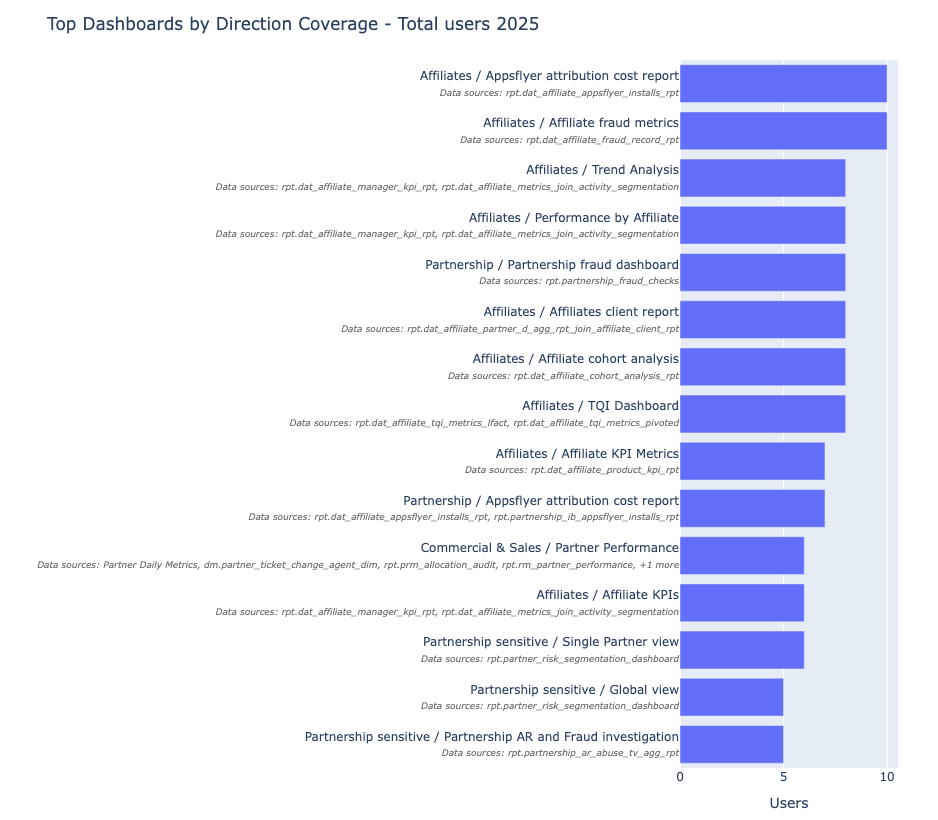

In [34]:
import pandas as pd
import plotly.graph_objects as go

# ============================
# 1. Prepare DataFrame
# ============================

df = pd.DataFrame(workbook_events)

df = df.explode("ds_name").explode("db_class")
df["ds_name"] = df["ds_name"].astype(str)
df["db_class"] = df["db_class"].astype(str)

df["view_full_name"] = df["project_name"] + " / " + df["view_name"]

# ============================
# 2. Data sources label
# ============================

def ds_compact(ds_iter, max_items=4):
    ds = sorted(set([x for x in ds_iter if x and x != "None"]))
    if not ds:
        return ""
    if len(ds) > max_items:
        ds = ds[:max_items] + [f"+{len(ds)-max_items} more"]
    return ", ".join(ds)

view_ds = (
    df.groupby("view_full_name")["ds_name"]
      .apply(lambda x: ds_compact(x, max_items=4))
      .to_dict()
)

df["view_label"] = df["view_full_name"].map(
    lambda v: (
        f"{v}"
        f"<br><span style='font-size:9px;color:#6d6e73;font-style:italic;'>"
        f"Data sources: {view_ds.get(v,'')}"
        f"</span>"
    )
)


# ============================
# 3. Report totals
# ============================

view_totals = (
    df.groupby(["view_full_name", "view_label"])
      .agg(
          total_users=("hist_actor_user_id", "nunique"),
          total_directions=("direction", "nunique"),
          total_departments=("department", "nunique"),
      )
      .reset_index()
)

# TOP-N views by total users
top_views_df = view_totals.sort_values("total_users", ascending=False).head(15).copy()
view_order = top_views_df["view_label"].tolist()  # already in correct order top->bottom

# make maps for fast lookup
meta_map = top_views_df.set_index("view_full_name")[["total_users", "total_directions", "total_departments"]].to_dict("index")
label_map = top_views_df.set_index("view_full_name")["view_label"].to_dict()

# ============================
# 4. Direction-level users per view
# ============================

view_direction = (
    df[df["view_full_name"].isin(top_views_df["view_full_name"])]
    .groupby(["view_full_name", "direction"])
    .agg(direction_users=("hist_actor_user_id", "nunique"))
    .reset_index()
)

# departments count per (view, direction)
dir_dept_cnt = (
    df[df["view_full_name"].isin(top_views_df["view_full_name"])]
    .groupby(["view_full_name", "direction"])
    .agg(direction_departments=("department", "nunique"))
    .reset_index()
)

dir_dept_cnt_map = dir_dept_cnt.set_index(["view_full_name", "direction"])["direction_departments"].to_dict()

# department breakdown per (view, direction)
view_dir_dept = (
    df[df["view_full_name"].isin(top_views_df["view_full_name"])]
    .groupby(["view_full_name", "direction", "department"])
    .agg(users=("hist_actor_user_id", "nunique"))
    .reset_index()
)

dir_dept_breakdown = (
    view_dir_dept
    .sort_values(["view_full_name", "direction", "users"], ascending=[True, True, False])
    .groupby(["view_full_name", "direction"])
    .apply(lambda x: "<br>".join(f"{r.department}: {r.users}" for r in x.itertuples()))
    .to_dict()
)

# add labels for plotting axis
view_direction["view_label"] = view_direction["view_full_name"].map(label_map)

# ============================
# 5. Build figure
# ============================

COLORS = {
    "yellow": "#ffde02",
    "mint": "#e1ebe5",
    "blue": "#47667b",
    "sage": "#93b39f",
    "black": "#131313",
    "grey": "#6d6e73",
    "orange": "#ffaa73",
    "light_blue": "#1271ca",
    "light_grey": "#6d6e73",
}

DIRECTION_COLOR_MAP = {
    "Trading": COLORS["blue"],
    "Payments": COLORS["orange"],
    "Administration": COLORS["sage"],
    "Marketing": COLORS["light_blue"],
    "Commercial": COLORS["yellow"],
    "Operations": COLORS["mint"],
    "Information Technology": COLORS["grey"],
}


fig = go.Figure()

directions = [d for d in view_direction["direction"].dropna().unique()]
directions.sort()

# enforce y order: we want top at top; for horizontal bars plotly shows first at bottom unless reversed
y_category_array = view_order[::-1]

for direction in directions:
    ddf = view_direction[view_direction["direction"] == direction].copy()

    # align points to y-axis category array (important for stable stacking)
    ddf["y_key"] = pd.Categorical(ddf["view_label"], categories=y_category_array, ordered=True)
    ddf = ddf.sort_values("y_key")

    # build per-point customdata aligned with this trace
    customdata = []
    for r in ddf.itertuples():
        v = r.view_full_name
        customdata.append([
            v,                                  # 0 full_name (for lookup)
            view_ds.get(v, ""),                 # 1 datasources text
            meta_map[v]["total_users"],         # 2 total users
            meta_map[v]["total_directions"],    # 3 total directions
            meta_map[v]["total_departments"],   # 4 total departments
            direction,                          # 5 selected direction (matches trace)
            r.direction_users,                  # 6 users in this direction
            dir_dept_cnt_map.get((v, direction), 0),  # 7 departments in this direction
            dir_dept_breakdown.get((v, direction), "") # 8 dept breakdown for this direction
        ])

    fig.add_trace(
        go.Bar(
            x=ddf["direction_users"],
            y=ddf["view_label"],
            name=direction,
            orientation="h",
            customdata=customdata,
           # marker=dict(color=DIRECTION_COLOR_MAP.get(direction, COLORS["light_grey"])),
            hovertemplate=
                "<b>%{y}</b><br>" +
              #  "<b>Data sources</b><br>%{customdata[1]}<br><br>" +
                "<b>Report overview</b><br>" +
                "Total users: %{customdata[2]}<br>" +
                "Total directions: %{customdata[3]}<br>" +
                "Total departments: %{customdata[4]}<br><br>" +
                "<b>Selected direction</b><br>" +
                "Direction: <b>%{customdata[5]}</b><br>" +
                "Users: %{customdata[6]}<br>" +
                "Departments: %{customdata[7]}<br><br>" +
                "<b>Departments breakdown (this direction)</b><br>" +
                "%{customdata[8]}" +
                "<extra></extra>"
        )
    )

# y-axis order locked
fig.update_yaxes(categoryorder="array", categoryarray=y_category_array)

fig.update_layout(
    title="Top Dashboards by Direction Coverage - Total users 2025",
    barmode="stack",
    legend_title="Direction",
    xaxis_title="Users",
    yaxis_title="",
    height=820,
    margin=dict(l=380, r=40, t=60, b=40)
)

fig.show()

fig.write_html(
    "plotly_tableau_top_dash_total_users_2025.html",
    include_plotlyjs="cdn",
    full_html=False
)


####  2.1.1 Table view

In [ ]:
# ============================
# Report-level totals
# ============================

report_totals = (
    df
    .groupby(["project_name", "view_name"])
    .agg(
        total_users=("hist_actor_user_id", "nunique"),
        total_directions=("direction", "nunique"),
        total_departments=("department", "nunique"),
        datasources=("ds_name", lambda x: ", ".join(sorted(set(
            d for d in x if d and d != "None"
        ))))
    )
    .reset_index()
)

# ============================
# Users per direction
# ============================

direction_users = (
    df
    .groupby(["project_name", "view_name", "direction"])
    .agg(
        users_in_direction=("hist_actor_user_id", "nunique")
    )
    .reset_index()
)

table_df = (
    direction_users
    .merge(
        report_totals,
        on=["project_name", "view_name"],
        how="left"
    )
    .sort_values(
        ["total_users", "users_in_direction"],
        ascending=[False, False]
    )
)
table_df.to_csv(
    "tableau_dashs_by_direction.csv",
    index=False
)
table_df.head(30)

#### 2.1.2 Filter by direction

/tmp/ipykernel_2102/3115245858.py:55: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



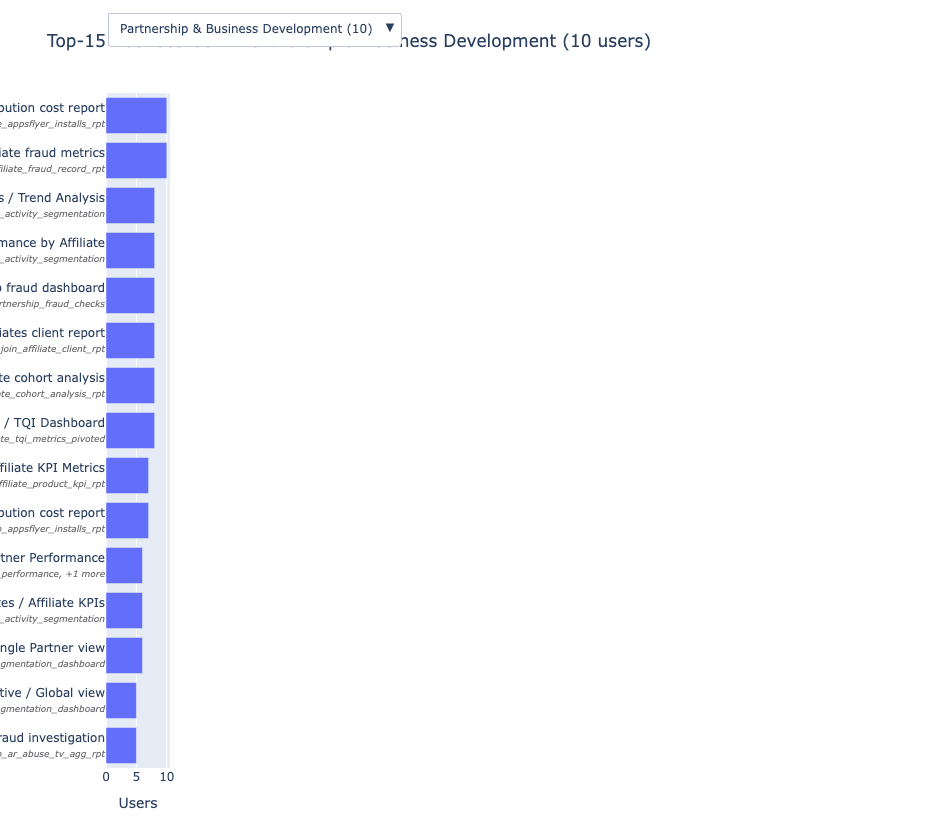

In [35]:
import pandas as pd
import plotly.graph_objects as go

# ============================
# 1. Prepare DataFrame
# ============================

df = pd.DataFrame(workbook_events)

df = df.explode("ds_name")
df["ds_name"] = df["ds_name"].astype(str)

df["view_full_name"] = df["project_name"] + " / " + df["view_name"]

# ============================
# 2. Data sources (compact label)
# ============================

def ds_compact(x, max_items=4):
    ds = sorted(set(d for d in x if d and d != "None"))
    if len(ds) > max_items:
        ds = ds[:max_items] + [f"+{len(ds)-max_items} more"]
    return ", ".join(ds)

view_ds = (
    df.groupby("view_full_name")["ds_name"]
      .apply(ds_compact)
      .to_dict()
)

# ============================
# 3. Users per (direction, view)
# ============================

vd = (
    df.groupby(["direction", "view_full_name"])
      .agg(users=("hist_actor_user_id", "nunique"))
      .reset_index()
)

# ============================
# 4. Departments per (direction, view)
# ============================

dir_view_dept = (
    df.groupby(["direction", "view_full_name", "department"])
      .agg(users=("hist_actor_user_id", "nunique"))
      .reset_index()
)

dept_tooltip = (
    dir_view_dept
    .sort_values(["direction", "view_full_name", "users"], ascending=[True, True, False])
    .groupby(["direction", "view_full_name"])
    .apply(lambda x: "<br>".join(
        f"{r.department}: {r.users}"
        for r in x.itertuples()
    ))
    .to_dict()
)

# ============================
# 5. Total users per direction (for dropdown)
# ============================

direction_users = (
    df.groupby("direction")["hist_actor_user_id"]
      .nunique()
      .reset_index(name="direction_users")
      .sort_values("direction_users", ascending=False)
)

# ============================
# 6. Precompute Top-15 per direction
# ============================

blocks = {}

for r in direction_users.itertuples():
    direction = r.direction

    tmp = vd[vd["direction"] == direction]

    top = (
        tmp.sort_values("users", ascending=False)
           .head(15)
           .iloc[::-1]   # reverse for horizontal bars
           .copy()
    )

    top["label"] = top["view_full_name"].map(
        lambda v: (
            f"{v}"
            f"<br><span style='font-size:9px;color:#6d6e73;font-style:italic;'>"
            f"Data sources: {view_ds.get(v,'')}"
            f"</span>"
        )
    )

    top["dept_breakdown"] = top["view_full_name"].map(
        lambda v: dept_tooltip.get((direction, v), "—")
    )

    blocks[direction] = top

# ============================
# 7. Init figure
# ============================

default_direction = direction_users.iloc[0].direction
init_df = blocks[default_direction]

fig = go.Figure(
    go.Bar(
        x=init_df["users"],
        y=init_df["label"],
        orientation="h",
        customdata=init_df["dept_breakdown"],
        hovertemplate=
            "<b>%{y}</b><br>" +
            "Users: %{x}<br><br>" +
            "<b>Departments (" + default_direction + ")</b><br>" +
            "%{customdata}" +
            "<extra></extra>"
    )
)

# ============================
# 8. Dropdown buttons
# ============================

buttons = []

for r in direction_users.itertuples():
    direction = r.direction
    users_cnt = r.direction_users
    ddf = blocks[direction]

    buttons.append(
        dict(
            label=f"{direction} ({users_cnt})",
            method="update",
            args=[
                {
                    "x": [ddf["users"]],
                    "y": [ddf["label"]],
                    "customdata": [ddf["dept_breakdown"]],
                },
                {
                    "title": f"Top-15 Dashboards - total users 2025 — {direction} ({users_cnt} users)"
                }
            ]
        )
    )

# ============================
# 9. Layout
# ============================

fig.update_layout(
    title=f"Top-15 Dashboards — {default_direction} ({direction_users.iloc[0].direction_users} users)",
    xaxis_title="Users",
    yaxis_title="",
    height=820,
    margin=dict(l=420, r=40, t=80, b=40),
    updatemenus=[
        dict(
            buttons=buttons,
            direction="down",
            showactive=True,
            x=0.01,
            y=1.12,
            xanchor="left",
            yanchor="top"
        )
    ]
)

fig.show()

fig.write_html(
    "plotly_tableau_top_dash_total_filter_by_direction.html",
    include_plotlyjs="cdn",
    full_html=False
)


#### Monthly Users 2025

/tmp/ipykernel_2102/2611450872.py:16: UserWarning:

Converting to PeriodArray/Index representation will drop timezone information.

/tmp/ipykernel_2102/2611450872.py:108: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



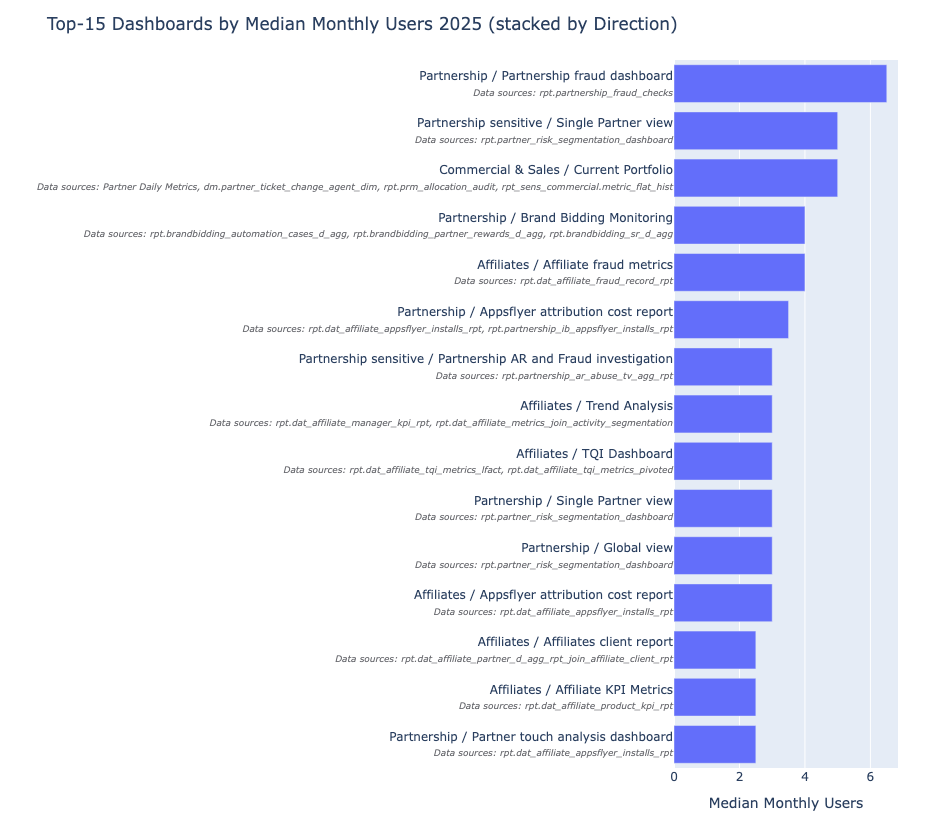

In [36]:
import pandas as pd
import plotly.graph_objects as go

# ============================
# 1. Prepare DataFrame
# ============================

df = pd.DataFrame(workbook_events)

df = df.explode("ds_name")
df["ds_name"] = df["ds_name"].astype(str)

df["view_full_name"] = df["project_name"] + " / " + df["view_name"]

# month for AMU
df["month"] = pd.to_datetime(df["event_month"]).dt.to_period("M").astype(str)


# ============================
# 2. Data sources label
# ============================

def ds_compact(x, max_items=4):
    ds = sorted(set(d for d in x if d and d != "None"))
    if len(ds) > max_items:
        ds = ds[:max_items] + [f"+{len(ds)-max_items} more"]
    return ", ".join(ds)

view_ds = (
    df.groupby("view_full_name")["ds_name"]
      .apply(ds_compact)
      .to_dict()
)

# ============================
# 3. Monthly users → AMU per (view, direction)
# ============================

monthly_usage = (
    df.groupby(["view_full_name", "direction", "month"])
      .agg(monthly_users=("hist_actor_user_id", "nunique"))
      .reset_index()
)

avg_usage = (
    monthly_usage
    .groupby(["view_full_name", "direction"])
    .agg(
        # avg_monthly_users=("monthly_users", "mean"),
        median_monthly_users = ("monthly_users", "median") ,

        active_months=("month", "nunique")
    )
    .reset_index()
)

# ============================
# 4. Total AMU per view (for TOP-15)
# ============================

view_mu = (
    avg_usage
    .groupby("view_full_name")
    .agg(total_mu=("median_monthly_users", "sum"))
    .reset_index()
)

top_views = (
    view_mu
    .sort_values("total_mu", ascending=False)
    .head(15)
)

# labels
top_views["view_label"] = top_views["view_full_name"].map(
    lambda v: (
        f"{v}"
        f"<br><span style='font-size:9px;color:#6d6e73;font-style:italic;'>"
        f"Data sources: {view_ds.get(v,'')}"
        f"</span>"
    )
)

label_map = top_views.set_index("view_full_name")["view_label"].to_dict()
order_labels = top_views["view_label"].tolist()[::-1]  # for horizontal bars

# ============================
# 5. Department avg monthly (tooltip)
# ============================

monthly_dept = (
    df.groupby(["view_full_name", "direction", "department", "month"])
      .agg(users=("hist_actor_user_id", "nunique"))
      .reset_index()
)

dept_avg = (
    monthly_dept
    .groupby(["view_full_name", "direction", "department"])
    .agg(monthly_users= ("users", "median"))
    .reset_index()
)

dept_tooltip = (
    dept_avg
    .sort_values(["view_full_name", "direction", "monthly_users"], ascending=[True, True, False])
    .groupby(["view_full_name", "direction"])
    .apply(lambda x: "<br>".join(
        f"{r.department}: {r.monthly_users:.1f}"
        for r in x.itertuples()
    ))
    .to_dict()
)

# ============================
# 6. Plot dataset
# ============================

plot_df = (
    avg_usage
    .merge(top_views[["view_full_name"]], on="view_full_name", how="inner")
)

plot_df["view_label"] = plot_df["view_full_name"].map(label_map)

# ============================
# 7. Build figure
# ============================

fig = go.Figure()

directions = sorted(plot_df["direction"].dropna().unique())

for direction in directions:
    ddf = plot_df[plot_df["direction"] == direction].copy()

    ddf["y_key"] = pd.Categorical(
        ddf["view_label"],
        categories=order_labels,
        ordered=True
    )
    ddf = ddf.sort_values("y_key")

    customdata = []
    for r in ddf.itertuples():
        customdata.append([
            r.median_monthly_users,
            r.active_months,
            dept_tooltip.get((r.view_full_name, direction), "—")
        ])

    fig.add_trace(
        go.Bar(
            x=ddf["median_monthly_users"],
            y=ddf["view_label"],
            name=direction,
            orientation="h",
            customdata=customdata,
            hovertemplate=
                "<b>%{y}</b><br><br>" +
                "<b>Selected direction</b><br>" +
                "Direction: <b>" + direction + "</b><br>" +
                "Median monthly users: %{customdata[0]:.1f}<br>" +
                "Active months: %{customdata[1]}<br><br>" +
                "<b>Departments (median monthly)</b><br>" +
                "%{customdata[2]}" +
                "<extra></extra>"
        )
    )

# ============================
# 8. Layout
# ============================

fig.update_yaxes(
    categoryorder="array",
    categoryarray=order_labels
)

fig.update_layout(
    title="Top-15 Dashboards by Median Monthly Users 2025 (stacked by Direction)",
    barmode="stack",
    legend_title="Direction",
    xaxis_title="Median Monthly Users",
    yaxis_title="",
    height=820,
    margin=dict(l=380, r=40, t=60, b=40)
)

fig.show()

fig.write_html(
    "plotly_tableau_top_dash_monthly_users_2025.html",
    include_plotlyjs="cdn",
    full_html=False
)


### 2.2. Top Data sources

In [ ]:
import pandas as pd
import plotly.graph_objects as go

# ============================
# 1. Prepare DataFrame
# ============================

df = pd.DataFrame(workbook_events)

df = df.explode("ds_name").explode("db_class")
df["ds_name"] = df["ds_name"].astype(str)
df["db_class"] = df["db_class"].astype(str)

# filter out empty / technical ds names if needed
df = df[df["ds_name"].notna() & (df["ds_name"] != "None")]

df["view_full_name"] = df["project_name"] + " / " + df["view_name"]

# ============================
# 2. Data Source totals (report-level)
# ============================

ds_totals = (
    df.groupby("ds_name")
      .agg(
          total_users=("hist_actor_user_id", "nunique"),
          total_views=("view_full_name", "nunique"),
          total_directions=("direction", "nunique"),
          total_departments=("department", "nunique"),
      )
      .reset_index()
)

# TOP-N data sources by users
top_ds_df = (
    ds_totals
    .sort_values("total_users", ascending=False)
    .head(15)
    .copy()
)

ds_order = top_ds_df["ds_name"].tolist()

meta_map = (
    top_ds_df
    .set_index("ds_name")
    .to_dict("index")
)

# ============================
# 3. Direction-level users per data source
# ============================

ds_direction = (
    df[df["ds_name"].isin(ds_order)]
    .groupby(["ds_name", "direction"])
    .agg(direction_users=("hist_actor_user_id", "nunique"))
    .reset_index()
)

# departments count per (ds, direction)
ds_dir_dept_cnt = (
    df[df["ds_name"].isin(ds_order)]
    .groupby(["ds_name", "direction"])
    .agg(direction_departments=("department", "nunique"))
    .reset_index()
)

ds_dir_dept_cnt_map = (
    ds_dir_dept_cnt
    .set_index(["ds_name", "direction"])["direction_departments"]
    .to_dict()
)

# department breakdown per (ds, direction)
ds_dir_dept = (
    df[df["ds_name"].isin(ds_order)]
    .groupby(["ds_name", "direction", "department"])
    .agg(users=("hist_actor_user_id", "nunique"))
    .reset_index()
)

ds_dir_dept_breakdown = (
    ds_dir_dept
    .sort_values(["ds_name", "direction", "users"], ascending=[True, True, False])
    .groupby(["ds_name", "direction"])
    .apply(lambda x: "<br>".join(f"{r.department}: {r.users}" for r in x.itertuples()))
    .to_dict()
)

# ============================
# 4. Direction order (auto, by impact)
# ============================

direction_order = (
    ds_direction
    .groupby("direction")["direction_users"]
    .sum()
    .sort_values(ascending=False)
    .index
    .tolist()
)

# ============================
# 5. Build figure
# ============================

fig = go.Figure()

# horizontal bar: first category is bottom → reverse
y_category_array = ds_order[::-1]

for direction in direction_order:
    ddf = ds_direction[ds_direction["direction"] == direction].copy()
    if ddf.empty:
        continue

    ddf["y_key"] = pd.Categorical(
        ddf["ds_name"],
        categories=y_category_array,
        ordered=True
    )
    ddf = ddf.sort_values("y_key")

    customdata = []
    for r in ddf.itertuples():
        ds = r.ds_name
        customdata.append([
            ds,                                      # 0 datasource
            meta_map[ds]["total_users"],             # 1 total users
            meta_map[ds]["total_views"],             # 2 total views
            meta_map[ds]["total_directions"],        # 3 total directions
            meta_map[ds]["total_departments"],       # 4 total departments
            direction,                               # 5 selected direction
            r.direction_users,                       # 6 users in this direction
            ds_dir_dept_cnt_map.get((ds, direction), 0),   # 7 departments in direction
            ds_dir_dept_breakdown.get((ds, direction), "") # 8 dept breakdown
        ])

    fig.add_trace(
        go.Bar(
            x=ddf["direction_users"],
            y=ddf["ds_name"],
            orientation="h",
            name=direction,
            customdata=customdata,
            hovertemplate=
                "<b>%{y}</b><br><br>" +
                "<b>Data source overview</b><br>" +
                "Total users: %{customdata[1]}<br>" +
                "Used in views: %{customdata[2]}<br>" +
                "Directions: %{customdata[3]}<br>" +
                "Departments: %{customdata[4]}<br><br>" +
                "<b>Selected direction</b><br>" +
                "Direction: <b>%{customdata[5]}</b><br>" +
                "Users: %{customdata[6]}<br>" +
                "Departments: %{customdata[7]}<br><br>" +
                "<b>Departments breakdown</b><br>" +
                "%{customdata[8]}" +
                "<extra></extra>"
        )
    )

# ============================
# 6. Layout
# ============================

fig.update_yaxes(
    categoryorder="array",
    categoryarray=y_category_array
)

fig.update_layout(
    title="Top Data Sources by Direction Coverage",
    barmode="stack",
    legend_title="Direction",
    xaxis_title="Users",
    yaxis_title="",
    height=820,
    margin=dict(l=320, r=40, t=60, b=40)
)

fig.show()

fig.write_html(
    "plotly_tableau_top_data_sources_2025.html",
    include_plotlyjs="cdn",
    full_html=False
)


In [ ]:
import pandas as pd

# ============================
# 1) Prepare DataFrame
# ============================
df = pd.DataFrame(workbook_events)

df = df.explode("ds_name").explode("db_class")
df["ds_name"] = df["ds_name"].astype(str)
df["db_class"] = df["db_class"].astype(str)

# filter out empty / technical ds names if needed
df = df[df["ds_name"].notna() & (df["ds_name"] != "None")]

# dashboard identifier (you can swap to something else if you have dashboard_id / url)
df["dashboard_full_name"] = df["project_name"].astype(str) + " / " + df["view_name"].astype(str)

# ============================
# 2) Table with related dashboards array
# ============================
ds_table = (
    df.groupby("ds_name")
      .agg(
          total_users=("hist_actor_user_id", "nunique"),
          total_dashboards=("dashboard_full_name", "nunique"),
          total_directions=("direction", "nunique"),
          total_departments=("department", "nunique"),
          related_dashboards=("dashboard_full_name", lambda s: sorted(set(s.dropna().astype(str)))),
      )
      .reset_index()
      .sort_values("total_users", ascending=False)
)

# Optional: keep only TOP-N data sources
ds_table = ds_table.head(15).copy()

# Optional: add a copy-friendly text version of the array (still keep the real list)
ds_table["related_dashboards_text"] = ds_table["related_dashboards"].apply(lambda x: "\n".join(x))

# Choose what you want to copy:
copy_df = ds_table[[
    "ds_name",
    "total_users",
    "total_dashboards",
    "total_directions",
    "total_departments",
    "related_dashboards_text",   # easy to paste/read
    # "related_dashboards",      # keep if you want the actual Python list in the table
]]

# ============================
# 3) Copyable output options
# ============================


import json

# Convert dashboards list → JSON string (safe for CSV)
ds_table["related_dashboards"] = ds_table["related_dashboards"].apply(json.dumps)

# Select final columns
final_df = ds_table[[
    "ds_name",
    "total_users",
    "total_dashboards",
    "total_directions",
    "total_departments",
    "related_dashboards"
]].copy()

# Save to CSV
final_df.to_csv(
    "top_data_sources_with_dashboards_2025.csv",
    index=False,
    encoding="utf-8"
)

print("CSV saved: top_data_sources_with_dashboards_2025.csv")



## Find team members by manager

In [ ]:
%%sql
    select * from (SELECT
			        uid,
			        -- take the text_value for the row with the greatest c.id per attribute
			        MAX_BY(val_text, val_id) FILTER (WHERE ota_id in (463,5736))                               AS user_name,
			        MAX_BY(val_text, val_id) FILTER (WHERE ota_id in (458,5727))                               AS job,--5727
			        MAX_BY(val_text, val_id) FILTER (WHERE ota_id = 456)                               AS direction,
			        MAX_BY(val_text, val_id) FILTER (WHERE ota_id in (457,5728))                               AS department, --5728
			        MAX_BY(val_text, val_id) FILTER (WHERE ota_id = 849)                               AS group_job,
			        MAX_BY(regexp_extract(val_text, '^uid=([^,]+)', 1), val_id) FILTER (WHERE ota_id in (5730,32287) ) as uid_manager, --32287
			        MAX_BY(boolean_value, val_id) FILTER (WHERE ota_id = 5753)  as deactivated
			    FROM
			    ( select distinct
			        SPLIT_PART(ep.label, '@', 1)                       AS uid,
			        attr.object_type_attribute_id                      AS ota_id,
			        c.id                                               AS val_id,
			        c.text_value                                       AS val_text,
			        c.boolean_value
			        , ref_obj.label as ref_obj_label
			        , ref_obj.name as ref_obj_name
			        , ref_obj.object_type_id as ref_obj_type_id
			        FROM delta.tech_data_platform_core.jira_ao_8542f1_ifj_obj ep
			        LEFT JOIN delta.tech_data_platform_core.jira_ao_8542f1_ifj_obj_attr attr
			            ON attr.object_id = ep.id
			        LEFT JOIN delta.tech_data_platform_core.jira_ao_8542f1_ifj_obj_attr_val c
			            ON c.object_attribute_id = attr.id
			        LEFT JOIN delta.tech_data_platform_core.jira_ao_8542f1_ifj_obj ref_obj
			            ON c.referenced_object_id = ref_obj.id
			        WHERE regexp_like(trim(lower(SPLIT_PART(ep.label, '@', 1))), '^[a-z]+[.][a-z]+$')
			          AND ep.label NOT LIKE '%/%'
			          AND attr.object_type_attribute_id IN (463,5736, 458, 456, 457, 849, 5730,5753 , 5727, 5728 , 32287)
			    ) src_jira
			    GROUP BY 1)
			    where uid_manager = 'mark.moiseev'

## find queries examples by table

### find queries examples by table - Vertica

In [ ]:
%%sql 
select count(*) from vertica_data_quality__ro.prometheus.query_requests_history v
where request_type = 'QUERY'
and start_timestamp >= date'2026-01-01'
and request != 'select now()::timestamptz'
--and transaction_id > 99079192741235774
and lower(request) like '%dat_affiliate_appsflyer_installs_rpt%'
and user_name not in ('etlmeta')

In [ ]:
%%sql
create table delta.tech_data_platform_work.astarostina_vertica_query_history
as 
    select 'dat_affiliate_appsflyer_installs_rpt' as table_name
    , v.* from vertica_data_quality__ro.prometheus.query_requests_history v
    where request_type = 'QUERY'
    and start_timestamp >= date'2026-01-01'
    and request != 'select now()::timestamptz'
    and lower(request) like '%dat_affiliate_appsflyer_installs_rpt%'
    and user_name not in ('etlmeta')


In [37]:
%%sql
    insert into table delta.tech_data_platform_work.astarostina_vertica_query_history
as 
    select 'rpt_partnership_fraud_checks' as table_name
    , v.* from vertica_data_quality__ro.prometheus.query_requests_history v
    where request_type = 'QUERY'
    and start_timestamp >= date'2026-01-01'
    and request != 'select now()::timestamptz'
    and lower(request) like '%partnership_fraud_checks%'
    and user_name not in ('etlmeta')

Running query in 'trino://trino.exness.io:443'

RuntimeError: If using snippets, you may pass the --with argument explicitly.
For more details please refer: https://jupysql.ploomber.io/en/latest/compose.html#with-argument


Original error message from DB driver:
(Your query contains named parameters (timestamptz) but the named parameters feature is "warn". 
Enable it with: %config SqlMagic.named_parameters="enabled" 
or disable it with: %config SqlMagic.named_parameters="disabled"
For more info, see the docs: https://jupysql.ploomber.io/en/latest/api/configuration.html#named-parameters)
(trino.exceptions.TrinoUserError) TrinoUserError(type=USER_ERROR, name=SYNTAX_ERROR, message="line 1:13: mismatched input 'table'. Expecting: <identifier>", query_id=20260218_145513_49324_jmrjp)
[SQL: insert into table delta.tech_data_platform_work.astarostina_vertica_query_history
as
    select 'rpt_partnership_fraud_checks' as table_name
    , v.* from vertica_data_quality__ro.prometheus.query_requests_history v
    where request_type = 'QUERY'
   

## find queries examples in data lake by users

In [ ]:
%%sql
select * from delta.tech_data_platform_work.astarostina_trino_analytical_queries
    where request_type != 'app'
    and u in ('mark.moiseev', 'justyna.zglenicka',
'daria.nichvidiuk',
'louis.zouein',
'valery.lazarev',
'daria.makarskaya',
'anton.lytyakov',
'alexey.samoylov',
'dmitry.pichugin',
'sergey.kovalev',
'margarita.karpiuk')
limit 10

In [25]:
from trino.dbapi import connect
from trino.auth import BasicAuthentication
import urllib3
from urllib3.exceptions import InsecureRequestWarning
import credscram
import pandas as pd
import re

urllib3.disable_warnings(InsecureRequestWarning)

conn = connect(
    host="trino.exness.io",
    port=443,
    auth=BasicAuthentication(credscram.creds.ldap_name, credscram.creds.ldap_pass),
    http_scheme="https",
    verify=False,
)


In [30]:
# ================================================================
# STREAMING, LOW-MEM TRINO VERSION
# Builds table usage stats without loading everything into RAM.
# ================================================================

import re
import hashlib
from collections import Counter, defaultdict

import pandas as pd

# ---------------- CONFIG ----------------

TRINO_INPUT_TABLE   = "delta.tech_data_platform_work.astarostina_trino_analytical_queries"
OUTPUT_CSV = "2_table_stats_team.csv"

CHUNKSIZE     = 250_000
MAX_QUERY_LEN = 2500

TOP_K_JOINS   = 15
TOP_K_COLS    = 20
TOP_K_QUERIES = 5

TEAM_UIDS = ('mark.moiseev', 'justyna.zglenicka', 'daria.nichvidiuk', 'louis.zouein', 'valery.lazarev',
'daria.makarskaya',
'anton.lytyakov',
'alexey.samoylov',
'dmitry.pichugin',
'sergey.kovalev',
'margarita.karpiuk')

# ---- EXCLUSIONS ----
EXCLUDE_JOIN_SCHEMAS = {
    "trading_work","tech_ml_platform_work","trading_pricing_work","tech_data_platform_work",
    "partnership_work","marketing_work","finance_work","protection_work","commercial_work",
    "payments_work","common_uploads","jdbc", "tech_data_platform_dbt_tmp_mart"
}

# ---------------- REGEX & HELPERS ----------------

def _strip_quotes(s: str) -> str:
    if not isinstance(s, str):
        return ""
    s = s.strip().replace('"','').replace('`','')
    return re.sub(r'^\[|\]$', '', s)

def _norm_ident(s: str) -> str:
    s = _strip_quotes(s)
    s = re.sub(r'\s+', ' ', s).strip().lower()
    return re.sub(r'[^a-z0-9._]', '', s)

CTE_NAME_RE     = re.compile(r'(?is)\b([`"\[]?[A-Za-z_][A-Za-z0-9_]*[`"\]]?)\s+as\s*\(')
TABLE_CLAUSE_RE = re.compile(r'(?is)\b(from|join|into|update|merge\s+into|table)\s+([`"\[\]A-Za-z0-9_.]+)')
JOIN_TARGET_RE  = re.compile(r'(?is)\bjoin\s+([`"\[\]A-Za-z0-9_.]+)')
COMMENT_RE     = re.compile(r"(--[^\n]*\n)|(/\*.*?\*/)", re.S | re.I)

SKIP_QUERY_RE = re.compile(
    r'''(?is)^\s*(?:--[^\n]*\n\s*|/\*.*?\*/\s*)*
        (?:create\s+(?:or\s+replace\s+)?(?:table|view)\b
           |insert\s+(?:overwrite\s+)?into\b)''',
    re.VERBOSE
)

EXCLUDE_NAMES    = {'unnest','lateral','values','if','case','true','false','null'}
EXCLUDE_PREFIXES = ('information_schema.', 'system.', 'sys.', 'sqlite_', '__temp__', '_tmp_', 'tmp_')

# ---------------- SQL PARSING ----------------

def _is_ddl_dml_to_skip(sql: str) -> bool:
    return bool(sql and SKIP_QUERY_RE.search(sql))

def extract_cte_names(sql: str) -> set:
    if not isinstance(sql, str) or not sql.strip():
        return set()
    if not re.search(r'(?is)^\s*with\b', sql):
        return set()
    return {_norm_ident(m.group(1)) for m in CTE_NAME_RE.finditer(sql)}

def looks_like_table(name: str) -> bool:
    if '.' not in name:
        return False
    if any(name.startswith(p) for p in EXCLUDE_PREFIXES):
        return False
    if name in EXCLUDE_NAMES:
        return False
    return True

def extract_tables(sql: str) -> set:
    ctes = extract_cte_names(sql)
    found = set()
    for m in TABLE_CLAUSE_RE.finditer(sql or ""):
        ident = _norm_ident(m.group(2))
        if ident and ident not in ctes and looks_like_table(ident):
            found.add(ident)
    return found

def extract_join_targets(sql: str) -> set:
    out = set()
    for m in JOIN_TARGET_RE.finditer(sql or ""):
        ident = _norm_ident(m.group(1))
        if ident and looks_like_table(ident):
            out.add(ident)
    return out

def _to_base_table(ident: str) -> str | None:
    parts = ident.split('.')
    if len(parts) == 3:
        return f"{parts[1]}.{parts[2]}"
    if len(parts) == 2:
        return ident
    return None

def _schema_of_base(bt: str) -> str | None:
    return bt.split('.', 1)[0] if '.' in bt else None

def find_columns_for_table(sql: str, base_table: str) -> list:
    try:
        schema, tbl = base_table.split('.', 1)
    except ValueError:
        return []
    return re.findall(
        rf'(?i)\b(?:{schema}\s*\.\s*)?{tbl}\s*\.\s*([a-z_][a-z0-9_]*)\b',
        sql or ""
    )

def _strip_sql_comments(sql: str) -> str:
    return COMMENT_RE.sub(" ", sql or "")

def _is_trivial_for_base(sql: str, base_table: str) -> bool:
    s = _strip_sql_comments(sql).lower()
    if re.search(r'\b(where|join|group\s+by|having|union|window)\b', s):
        return False
    if re.search(r'\b(count|sum|avg|min|max)\s*\(|\bover\b', s):
        return False
    tables = {_to_base_table(t) for t in extract_tables(sql) if _to_base_table(t)}
    return tables == {base_table}

def _normalize_and_truncate_query(q: str) -> str:
    q = re.sub(r'\s+', ' ', q or "").strip()
    return q[:MAX_QUERY_LEN]

def hash64(s: str) -> bytes:
    return hashlib.blake2b(s.encode("utf-8"), digest_size=8).digest()

# ---------------- ACCUMULATORS ----------------

join_counter     = defaultdict(Counter)
join_kw_counter  = defaultdict(Counter)
column_counter   = defaultdict(Counter)
sample_counter   = defaultdict(Counter)

total_weight_per_bt = defaultdict(int)
users_set        = defaultdict(set)
query_hash_set   = defaultdict(set)
catalogs_set     = defaultdict(set)

# ---------------- TRINO STREAM ----------------


SQL = f"""
SELECT
    query_norm as query,
    u as "user",
    count(*) AS num_queries
FROM {TRINO_INPUT_TABLE}
where u in {TEAM_UIDS}
group by 1,2
"""

df_iter = pd.read_sql_query(SQL, conn, chunksize=CHUNKSIZE)

# ---------------- MAIN LOOP ----------------

total_rows = 0

for chunk in df_iter:
    chunk = chunk.dropna(subset=["query"]).drop_duplicates(subset=["query","user"])

    for q, u, w in zip(chunk["query"], chunk["user"], chunk["num_queries"]):
        total_rows += 1
        w = int(w) if w and w > 0 else 1

        if _is_ddl_dml_to_skip(q):
            continue

        tables = extract_tables(q)
        joins  = extract_join_targets(q)
        if not tables:
            continue

        base_set = {_to_base_table(t) for t in tables if _to_base_table(t)}
        base_set = {b for b in base_set if _schema_of_base(b) not in EXCLUDE_JOIN_SCHEMAS}
        if not base_set:
            continue

        for t in tables:
            p = _norm_ident(t).split(".")
            if len(p) == 3 and p[0] in {"delta","iceberg"}:
                catalogs_set[f"{p[1]}.{p[2]}"].add(p[0])

        q_short = _normalize_and_truncate_query(q)

        for bt in base_set:
            total_weight_per_bt[bt] += w
            if u:
                users_set[bt].add(u)

            for o in base_set - {bt}:
                join_counter[bt][o] += w

            for o in {_to_base_table(j) for j in joins if _to_base_table(j)} - {bt}:
                join_kw_counter[bt][o] += w

            if not _is_trivial_for_base(q, bt):
                for c in find_columns_for_table(q, bt):
                    column_counter[bt][c] += w
                sample_counter[bt][q_short] += w
                query_hash_set[bt].add(hash64(q_short))

    if total_rows % 500_000 == 0:
        print(f"[progress] processed ~{total_rows:,} rows")

# ---------------- BUILD OUTPUT ----------------

def top_list(cnt: Counter, k: int):
    return [x for x, _ in cnt.most_common(k)]

rows = []
for bt in sorted(set(users_set)):
    rows.append({
        "base_table": bt,
        "queries_cnt": len(query_hash_set[bt]),
        "queries_cnt_w": total_weight_per_bt[bt],
        "users_cnt": len(users_set[bt]),
        "users_list": sorted(users_set[bt]),
        "catalogs": sorted(catalogs_set.get(bt, [])),
        "top_joins": top_list(join_kw_counter[bt] or join_counter[bt], TOP_K_JOINS),
        "top_columns": top_list(column_counter[bt], TOP_K_COLS),
        "sample_queries": top_list(sample_counter[bt], TOP_K_QUERIES),
    })

out = pd.DataFrame(rows)
out.to_csv(OUTPUT_CSV, index=False)

print(f"[done] Saved {OUTPUT_CSV} | rows={len(out)} | processed={total_rows:,}")


/tmp/ipykernel_2102/1608821081.py:170: UserWarning:

pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.



[done] Saved 2_table_stats_team.csv | rows=206 | processed=13,583
